# Lecture 18 - (05/05/2026)

Today's Topics:

- Building a Network
- Introducing PyTorch


In [9]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

## Building a Network

Let's callback to logistic regression:

$$ [x_1, x_2, x_3, \cdots, x_n] \xrightarrow{} \text{Logistic Regression} \xrightarrow{} probability $$

where:

$$ Pr(Y=1) = \frac{1}{1+e^{-(\beta_0+\beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n)}}$$

In [18]:
df = pd.read_csv('https://raw.githubusercontent.com/nnamdijuugo/gpa_dataset/refs/heads/master/gpa1.csv')
df = df.drop(columns=['rank_2', 'rank_3', 'rank_4'])

df.head()

,admit,gre,gpa
0,0,380,3.61
1,1,660,3.67
2,1,800,4.00
3,1,640,3.19
4,0,520,2.93


Given independent variables:
- GRE
- GPA

predict who will be admitted to a university.

We can estimate this logistic regression model and find values for the coefficients:

In [19]:
from sklearn.linear_model import LogisticRegression

y = df['admit']
X = df.drop(columns=['admit'])

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

print(model.coef_)
print(model.intercept_)

[[0.00276914 0.68500788]]
[-4.7569233]


$$ P(Y=1) = \frac{1}{1+e^{-(-4.76 + 0.00*\text{gre} + 0.69*\text{gpa})}}

We can re-write this formula as a network with input data flowing through five functions that have been connected.

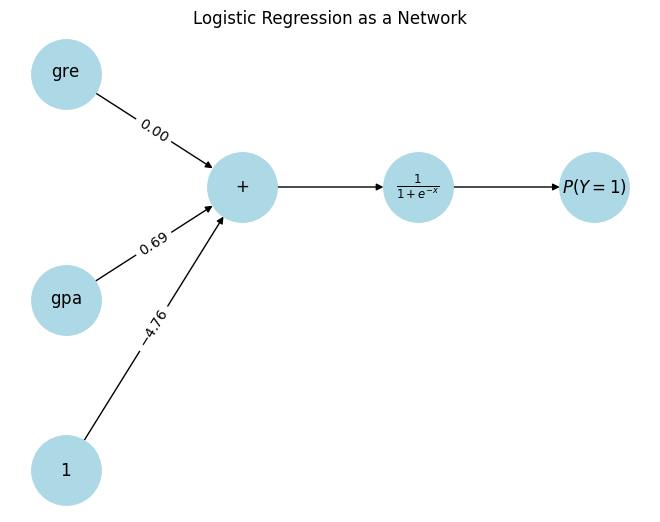

In [25]:
G = nx.DiGraph()

inputs = ['gre', 'gpa']
bias = 'bias'
sum_node = 'sum'
sigmoid = 'sigmoid'
output = 'output'

G.add_nodes_from(inputs + [bias, sum_node, sigmoid, output])

G.add_edge('gre', sum_node, weight=0.00)
G.add_edge('gpa', sum_node, weight=0.69)
G.add_edge(bias, sum_node, weight=-4.76)

G.add_edge(sum_node, sigmoid)
G.add_edge(sigmoid, output)

pos = {
    'gre': (0, 1),
    'gpa': (0, -1),
    'bias': (0, -2.5),
    'sum': (2, 0),
    'sigmoid': (4, 0),
    'output': (6, 0)
}

labels = {
    'gre': r'$\mathrm{gre}$',
    'gpa': r'$\mathrm{gpa}$',
    'bias': r'$1$',
    'sum': r'$+$',
    'sigmoid': r'$\frac{1}{1+e^{-x}}$',
    'output': r'$P(Y=1)$'
}

nx.draw(
    G, pos,
    labels=labels,
    with_labels=True,
    node_size=2500,
    node_color='lightblue'
)

edge_labels = {
    (u, v): rf'${d["weight"]:.2f}$'
    for u, v, d in G.edges(data=True)
    if 'weight' in d
}

nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Logistic Regression as a Network")
plt.show()

Let’s make a prediction with this “network”. Consider a applicant with a GPA of 3.6 and 790 on the GRE.

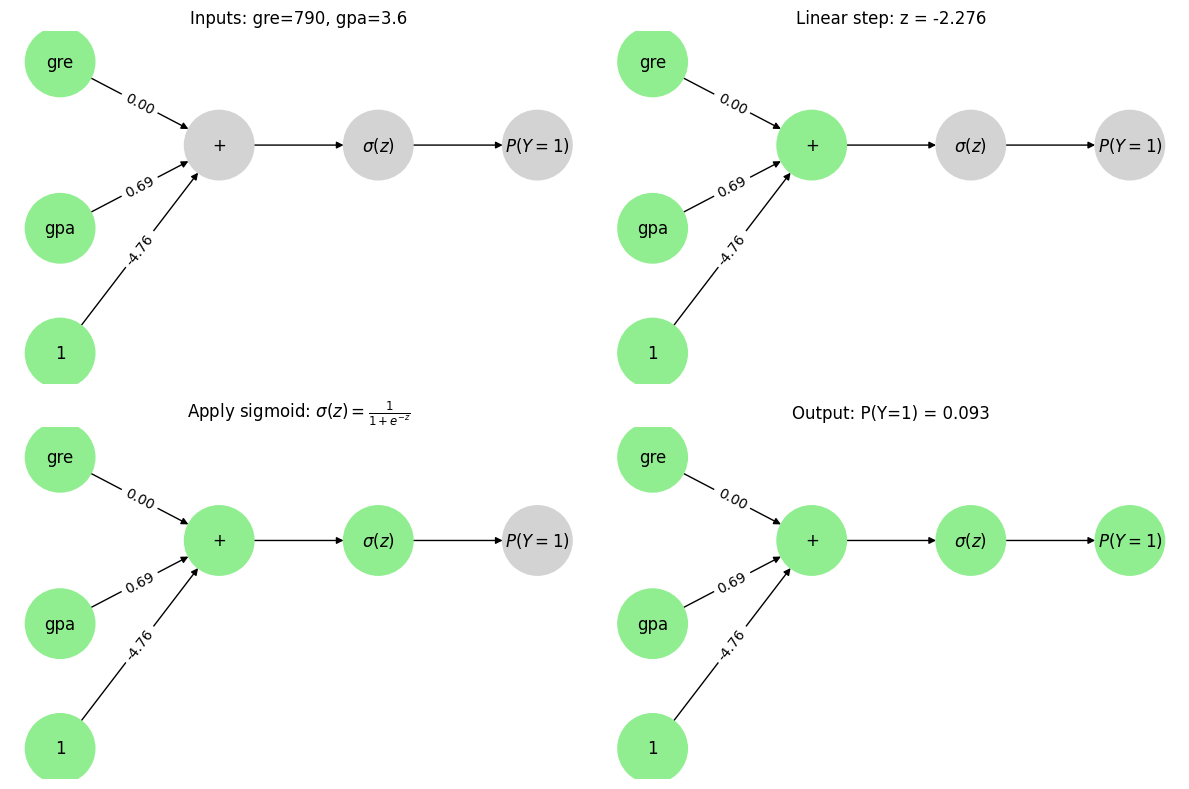

In [27]:
import networkx as nx
import matplotlib.pyplot as plt
import math

# -----------------------
# Graph setup
# -----------------------
G = nx.DiGraph()

inputs = ['gre', 'gpa']
bias = 'bias'
sum_node = 'sum'
sigmoid = 'sigmoid'
output = 'output'

G.add_nodes_from(inputs + [bias, sum_node, sigmoid, output])

G.add_edge('gre', sum_node, weight=0.00)
G.add_edge('gpa', sum_node, weight=0.69)
G.add_edge(bias, sum_node, weight=-4.76)

G.add_edge(sum_node, sigmoid)
G.add_edge(sigmoid, output)

pos = {
    'gre': (0, 1),
    'gpa': (0, -1),
    'bias': (0, -2.5),
    'sum': (2, 0),
    'sigmoid': (4, 0),
    'output': (6, 0)
}

labels = {
    'gre': 'gre',
    'gpa': 'gpa',
    'bias': '1',
    'sum': '+',
    'sigmoid': r'$\sigma(z)$',
    'output': r'$P(Y=1)$'
}

edge_labels = {
    (u, v): f"{d['weight']:.2f}"
    for u, v, d in G.edges(data=True)
    if 'weight' in d
}

# -----------------------
# Data
# -----------------------
gre = 790
gpa = 3.6

z = -4.76 + 0.00 * gre + 0.69 * gpa
p = 1 / (1 + math.exp(-z))

# -----------------------
# Helper for drawing states
# -----------------------
def draw(ax, active_nodes, title):
    colors = [
        'lightgreen' if n in active_nodes else 'lightgray'
        for n in G.nodes
    ]

    nx.draw(G, pos, labels=labels, node_color=colors,
            node_size=2500, ax=ax)

    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax)

    ax.set_title(title)
    ax.axis('off')

# -----------------------
# Figure with 4 panels
# -----------------------
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Frame 1: inputs
draw(axs[0, 0],
     ['gre', 'gpa', 'bias'],
     f"Inputs: gre={gre}, gpa={gpa}")

# Frame 2: sum
draw(axs[0, 1],
     ['gre', 'gpa', 'bias', 'sum'],
     f"Linear step: z = {z:.3f}")

# Frame 3: sigmoid
draw(axs[1, 0],
     ['gre', 'gpa', 'bias', 'sum', 'sigmoid'],
     r"Apply sigmoid: $\sigma(z)=\frac{1}{1+e^{-z}}$")

# Frame 4: output
draw(axs[1, 1],
     ['gre', 'gpa', 'bias', 'sum', 'sigmoid', 'output'],
     f"Output: P(Y=1) = {p:.3f}")

plt.tight_layout()
plt.show()

This result is the exact same as the equation we made to model it. Notice that the data flows through the network from left to right.

- Multipliers on values from each node = coefficients = weights
- Intercept = bias

What’s the advantage of viewing through a network “lens”?


To make smarter representations, we would like to transform the inputs one or more times before we do the prediction.

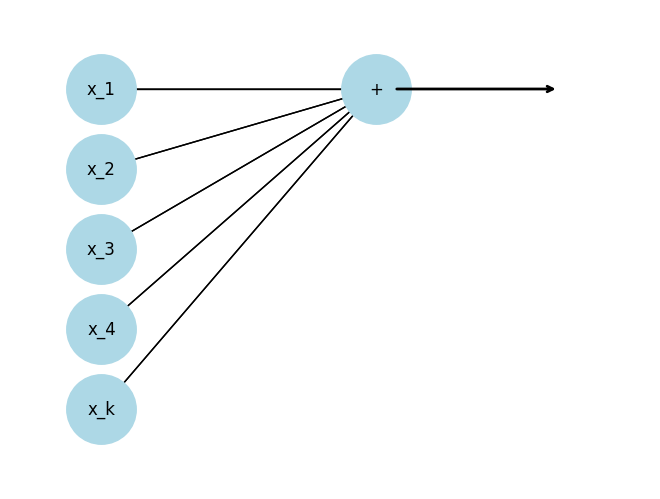

In [30]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

features = ['x_1', 'x_2', 'x_3', 'x_4', 'x_k']
plus_node = '+'

G.add_nodes_from(features + [plus_node])

for f in features:
    G.add_edge(f, plus_node)

pos = {
    'x_1': (0, 4),
    'x_2': (0, 3),
    'x_3': (0, 2),
    'x_4': (0, 1),
    'x_k': (0, 0),
    '+': (3, 4)
}

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    node_color='lightblue',
    arrows=False
)

nx.draw_networkx_edges(G, pos, arrows=True)

ax = plt.gca()

ax.annotate(
    '',
    xy=(5, 4),
    xytext=(3.2, 4),
    arrowprops=dict(arrowstyle='->', lw=2)
)

ax.set_xlim(-1, 6)
ax.set_ylim(-1, 5)

plt.axis('off')
plt.show()

We can ”stack” as many linear functions as we want

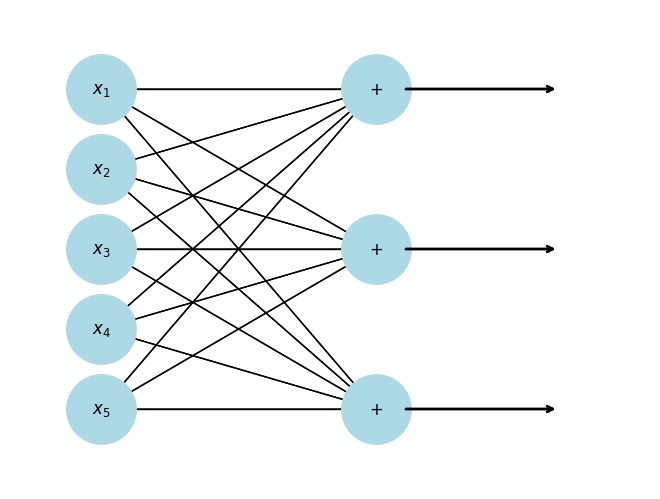

In [34]:
G = nx.DiGraph()

features = ['x_1', 'x_2', 'x_3', 'x_4', 'x_5']
plus_nodes = ['+_1', '+_2', '+_3']

G.add_nodes_from(features + plus_nodes)

for f in features:
    for p in plus_nodes:
        G.add_edge(f, p)

pos = {
    'x_1': (0, 4),
    'x_2': (0, 3),
    'x_3': (0, 2),
    'x_4': (0, 1),
    'x_5': (0, 0),

    '+_1': (3, 4),
    '+_2': (3, 2),
    '+_3': (3, 0)
}

labels = {
    'x_1': r'$x_1$',
    'x_2': r'$x_2$',
    'x_3': r'$x_3$',
    'x_4': r'$x_4$',
    'x_5': r'$x_5$',
    '+_1': r'$+$',
    '+_2': r'$+$',
    '+_3': r'$+$'
}

nx.draw(
    G,
    pos,
    labels=labels,
    with_labels=True,
    node_size=2500,
    node_color='lightblue',
    arrows=False
)

nx.draw_networkx_edges(G, pos, arrows=True)

ax = plt.gca()

for y in [4, 2, 0]:
    ax.annotate(
        '',
        xy=(5, y),
        xytext=(3.3, y),
        arrowprops=dict(arrowstyle='->', lw=2)
    )

ax.set_xlim(-1, 6)
ax.set_ylim(-1, 5)

plt.axis('off')
plt.show()

Notice that we have transformed a 5-dimensional input to a 3-dimensional vector. We can “flow” this 3-dimensional vector through another function.

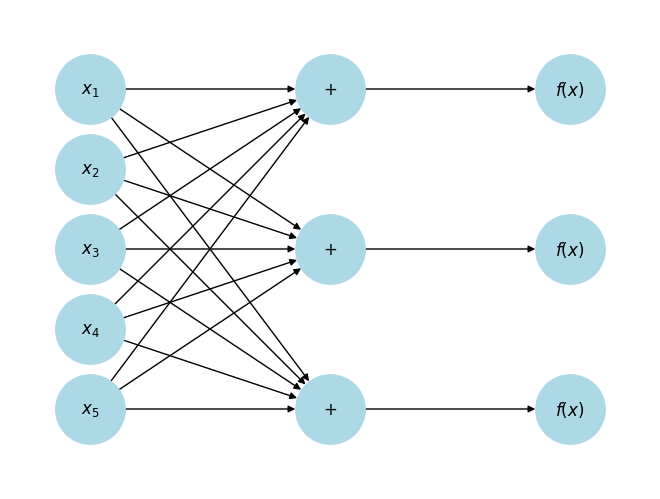

In [40]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

features = ['x_1', 'x_2', 'x_3', 'x_4', 'x_5']
plus_nodes = ['+_1', '+_2', '+_3']
f_nodes = ['f_1', 'f_2', 'f_3']

G.add_nodes_from(features + plus_nodes + f_nodes)

for f in features:
    for p in plus_nodes:
        G.add_edge(f, p)

G.add_edge('+_1', 'f_1')
G.add_edge('+_2', 'f_2')
G.add_edge('+_3', 'f_3')

pos = {
    'x_1': (0, 4),
    'x_2': (0, 3),
    'x_3': (0, 2),
    'x_4': (0, 1),
    'x_5': (0, 0),

    '+_1': (3, 4),
    '+_2': (3, 2),
    '+_3': (3, 0),

    'f_1': (6, 4),
    'f_2': (6, 2),
    'f_3': (6, 0)
}

labels = {
    'x_1': r'$x_1$',
    'x_2': r'$x_2$',
    'x_3': r'$x_3$',
    'x_4': r'$x_4$',
    'x_5': r'$x_5$',
    '+_1': r'$+$',
    '+_2': r'$+$',
    '+_3': r'$+$',
    'f_1': r'$f(x)$',
    'f_2': r'$f(x)$',
    'f_3': r'$f(x)$'
}

nx.draw(
    G,
    pos,
    labels=labels,
    with_labels=True,
    node_size=2500,
    node_color='lightblue',
    arrows=True
)

ax = plt.gca()
ax.set_xlim(-1, 7)
ax.set_ylim(-1, 5)

plt.axis('off')
plt.show()

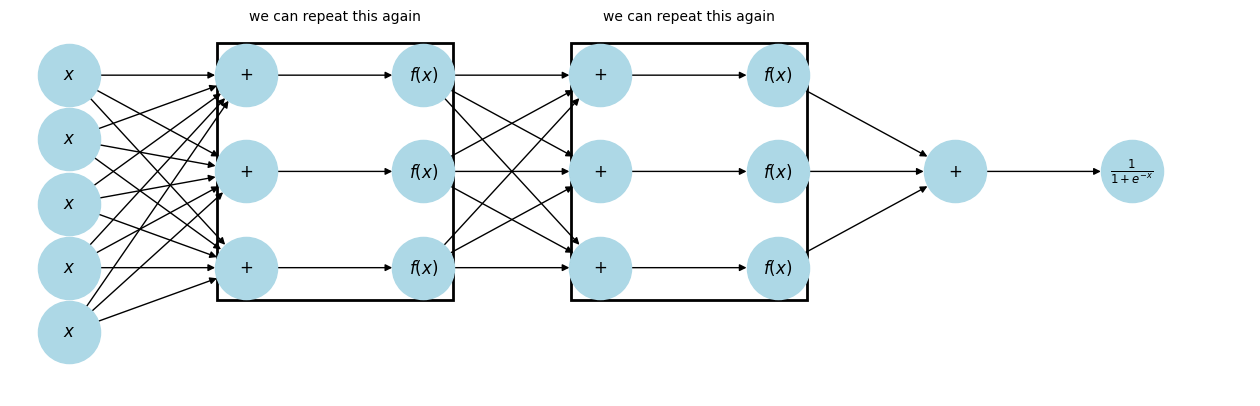

In [48]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

G = nx.DiGraph()

x_nodes = ['x_1', 'x_2', 'x_3', 'x_4', 'x_5']

plus1 = ['+_1', '+_2', '+_3']
f1 = ['f_1', 'f_2', 'f_3']

plus2 = ['+_4', '+_5', '+_6']
f2 = ['f_4', 'f_5', 'f_6']

plus3 = ['+_7']
sigmoid = ['sigmoid']

G.add_nodes_from(x_nodes + plus1 + f1 + plus2 + f2 + plus3 + sigmoid)

for x in x_nodes:
    for p in plus1:
        G.add_edge(x, p)

G.add_edge('+_1', 'f_1')
G.add_edge('+_2', 'f_2')
G.add_edge('+_3', 'f_3')

for f in f1:
    for p in plus2:
        G.add_edge(f, p)

G.add_edge('+_4', 'f_4')
G.add_edge('+_5', 'f_5')
G.add_edge('+_6', 'f_6')

for f in f2:
    G.add_edge(f, '+_7')

G.add_edge('+_7', 'sigmoid')

pos = {
    'x_1': (0, 4),
    'x_2': (0, 3),
    'x_3': (0, 2),
    'x_4': (0, 1),
    'x_5': (0, 0),

    '+_1': (3, 4),
    '+_2': (3, 2.5),
    '+_3': (3, 1),

    'f_1': (6, 4),
    'f_2': (6, 2.5),
    'f_3': (6, 1),

    '+_4': (9, 4),
    '+_5': (9, 2.5),
    '+_6': (9, 1),

    'f_4': (12, 4),
    'f_5': (12, 2.5),
    'f_6': (12, 1),

    '+_7': (15, 2.5),
    'sigmoid': (18, 2.5)
}

labels = {
    **{n: (r'$x$' if 'x_' in n else (r'$+$' if '+' in n else r'$f(x)$')) for n in G.nodes},
    'sigmoid': r'$\frac{1}{1+e^{-x}}$'
}

fig, ax = plt.subplots(figsize=(16, 5))

nx.draw(
    G,
    pos,
    labels=labels,
    with_labels=True,
    node_size=2000,
    node_color='lightblue',
    arrows=True,
    ax=ax
)

def box(nodes, text):
    xs = [pos[n][0] for n in nodes]
    ys = [pos[n][1] for n in nodes]
    xmin, xmax = min(xs) - 0.5, max(xs) + 0.5
    ymin, ymax = min(ys) - 0.5, max(ys) + 0.5

    rect = Rectangle(
        (xmin, ymin),
        xmax - xmin,
        ymax - ymin,
        fill=False,
        linewidth=2
    )
    ax.add_patch(rect)

    ax.text(
        (xmin + xmax) / 2,
        ymax + 0.3,
        "we can repeat this again",
        ha='center',
        va='bottom'
    )

box(plus1 + f1, "we can repeat this again")
box(plus2 + f2, "and again")

ax.set_xlim(-1, 20)
ax.set_ylim(-1, 5)

plt.axis('off')
plt.show()

This is a Neural Network! The summation nodes connecting to the $f(x)$'s are reffered to as neurons.

![image](https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fwww.open.edu%2Fopenlearn%2Fpluginfile.php%2F3408855%2Fmod_oucontent%2Foucontent%2F111755%2Fa5329190%2Fb2d52a0b%2Fwk6_fig4.tif.jpg&f=1&nofb=1&ipt=38d4dfad66728eb85e686abe752b6937b145e2bb859cdeddf2a9a9458c6921c4)

In the brain, the dendrites of one neuron connect to the axons of
others at synapses, forming a network.

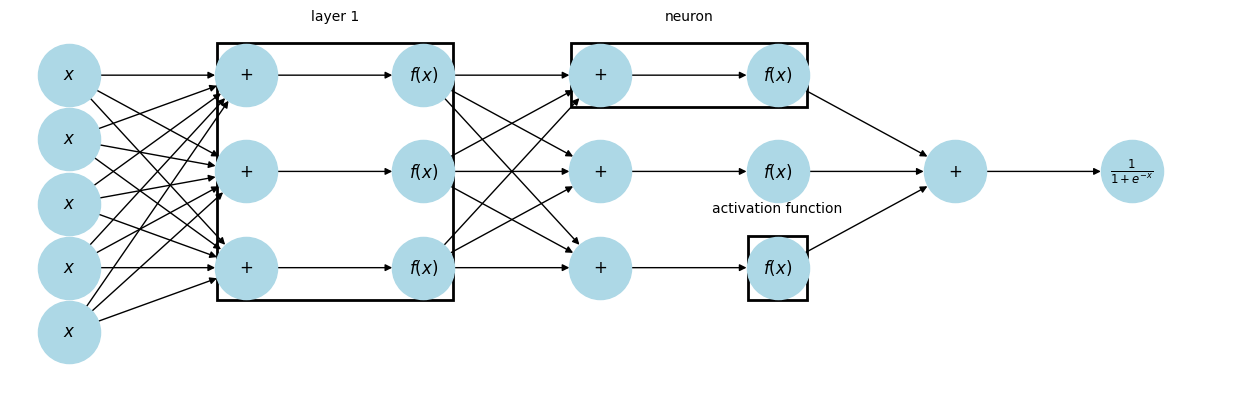

In [50]:
G = nx.DiGraph()

x_nodes = ['x_1', 'x_2', 'x_3', 'x_4', 'x_5']

plus1 = ['+_1', '+_2', '+_3']
f1 = ['f_1', 'f_2', 'f_3']

plus2 = ['+_4', '+_5', '+_6']
f2 = ['f_4', 'f_5', 'f_6']

plus3 = ['+_7']
sigmoid = ['sigmoid']

G.add_nodes_from(x_nodes + plus1 + f1 + plus2 + f2 + plus3 + sigmoid)

for x in x_nodes:
    for p in plus1:
        G.add_edge(x, p)

G.add_edge('+_1', 'f_1')
G.add_edge('+_2', 'f_2')
G.add_edge('+_3', 'f_3')

for f in f1:
    for p in plus2:
        G.add_edge(f, p)

G.add_edge('+_4', 'f_4')
G.add_edge('+_5', 'f_5')
G.add_edge('+_6', 'f_6')

for f in f2:
    G.add_edge(f, '+_7')

G.add_edge('+_7', 'sigmoid')

pos = {
    'x_1': (0, 4),
    'x_2': (0, 3),
    'x_3': (0, 2),
    'x_4': (0, 1),
    'x_5': (0, 0),

    '+_1': (3, 4),
    '+_2': (3, 2.5),
    '+_3': (3, 1),

    'f_1': (6, 4),
    'f_2': (6, 2.5),
    'f_3': (6, 1),

    '+_4': (9, 4),
    '+_5': (9, 2.5),
    '+_6': (9, 1),

    'f_4': (12, 4),
    'f_5': (12, 2.5),
    'f_6': (12, 1),

    '+_7': (15, 2.5),
    'sigmoid': (18, 2.5)
}

labels = {
    **{n: (r'$x$' if 'x_' in n else (r'$+$' if '+' in n else r'$f(x)$')) for n in G.nodes},
    'sigmoid': r'$\frac{1}{1+e^{-x}}$'
}

fig, ax = plt.subplots(figsize=(16, 5))

nx.draw(
    G,
    pos,
    labels=labels,
    with_labels=True,
    node_size=2000,
    node_color='lightblue',
    arrows=True,
    ax=ax
)

def box(nodes, text):
    xs = [pos[n][0] for n in nodes]
    ys = [pos[n][1] for n in nodes]
    xmin, xmax = min(xs) - 0.5, max(xs) + 0.5
    ymin, ymax = min(ys) - 0.5, max(ys) + 0.5

    rect = Rectangle(
        (xmin, ymin),
        xmax - xmin,
        ymax - ymin,
        fill=False,
        linewidth=2
    )
    ax.add_patch(rect)

    ax.text(
        (xmin + xmax) / 2,
        ymax + 0.3,
        text,
        ha='center',
        va='bottom'
    )

# -----------------------------
# Layer 1 box: +_1..+_3 and f_1..f_3
# -----------------------------
box(plus1 + f1, "layer 1")

# -----------------------------
# Single neuron box: +_4 and f_4
# -----------------------------
box(['+_4', 'f_4'], "neuron")

# -----------------------------
# Activation function: f_6 only
# -----------------------------
box(['f_6'], "activation function")

ax.set_xlim(-1, 20)
ax.set_ylim(-1, 5)

plt.axis('off')
plt.show()

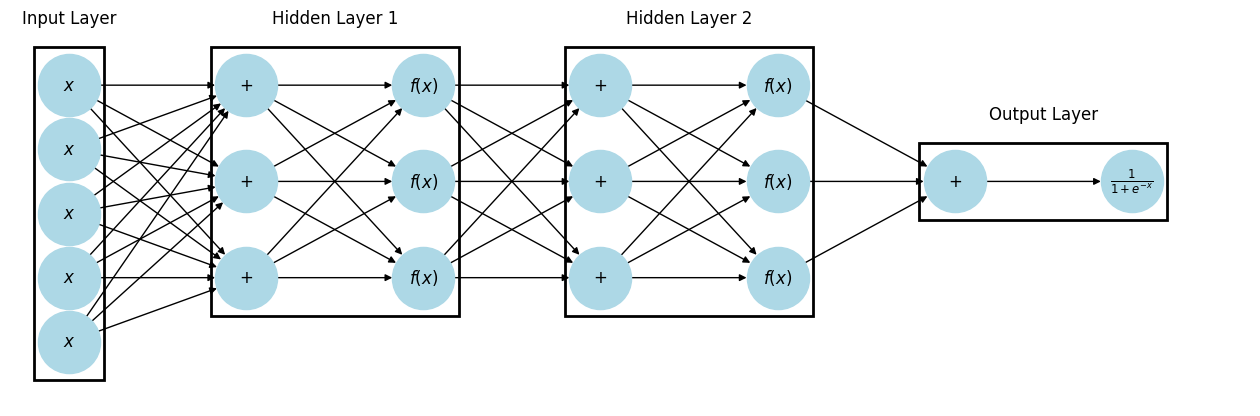

In [53]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

G = nx.DiGraph()

x_nodes = ['x_1', 'x_2', 'x_3', 'x_4', 'x_5']

plus1 = ['+_1', '+_2', '+_3']
f1 = ['f_1', 'f_2', 'f_3']

plus2 = ['+_4', '+_5', '+_6']
f2 = ['f_4', 'f_5', 'f_6']

plus3 = ['+_7']
sigmoid = ['sigmoid']

G.add_nodes_from(x_nodes + plus1 + f1 + plus2 + f2 + plus3 + sigmoid)

# Input -> Hidden 1
for x in x_nodes:
    for p in plus1:
        G.add_edge(x, p)

for p in plus1:
    G.add_edge(p, 'f_1')
    G.add_edge(p, 'f_2')
    G.add_edge(p, 'f_3')

# Hidden 1 -> Hidden 2
for f in f1:
    for p in plus2:
        G.add_edge(f, p)

for p in plus2:
    G.add_edge(p, 'f_4')
    G.add_edge(p, 'f_5')
    G.add_edge(p, 'f_6')

# Hidden 2 -> Output layer
for f in f2:
    G.add_edge(f, '+_7')

G.add_edge('+_7', 'sigmoid')

pos = {
    'x_1': (0, 4),
    'x_2': (0, 3),
    'x_3': (0, 2),
    'x_4': (0, 1),
    'x_5': (0, 0),

    '+_1': (3, 4),
    '+_2': (3, 2.5),
    '+_3': (3, 1),

    'f_1': (6, 4),
    'f_2': (6, 2.5),
    'f_3': (6, 1),

    '+_4': (9, 4),
    '+_5': (9, 2.5),
    '+_6': (9, 1),

    'f_4': (12, 4),
    'f_5': (12, 2.5),
    'f_6': (12, 1),

    '+_7': (15, 2.5),
    'sigmoid': (18, 2.5)
}

labels = {
    **{n: (r'$x$' if 'x_' in n else (r'$+$' if '+' in n else r'$f(x)$')) for n in G.nodes},
    'sigmoid': r'$\frac{1}{1+e^{-x}}$'
}

fig, ax = plt.subplots(figsize=(16, 5))

nx.draw(
    G,
    pos,
    labels=labels,
    with_labels=True,
    node_size=2000,
    node_color='lightblue',
    arrows=True,
    ax=ax
)

def box(nodes, text):
    xs = [pos[n][0] for n in nodes]
    ys = [pos[n][1] for n in nodes]

    xmin, xmax = min(xs) - 0.6, max(xs) + 0.6
    ymin, ymax = min(ys) - 0.6, max(ys) + 0.6

    rect = Rectangle(
        (xmin, ymin),
        xmax - xmin,
        ymax - ymin,
        fill=False,
        linewidth=2
    )
    ax.add_patch(rect)

    ax.text(
        (xmin + xmax) / 2,
        ymax + 0.3,
        text,
        ha='center',
        va='bottom',
        fontsize=12
    )

# Input layer
box(x_nodes, "Input Layer")

# Hidden layer 1
box(plus1 + f1, "Hidden Layer 1")

# Hidden layer 2
box(plus2 + f2, "Hidden Layer 2")

# Output layer (NOW includes +_7 and sigmoid)
box(plus3 + sigmoid, "Output Layer")

ax.set_xlim(-1, 20)
ax.set_ylim(-1, 5)

plt.axis('off')
plt.show()

When every neuron in a layer is connected to every neuron in the next
layer, it is called Dense or Fully Connected. Deep Learning is just neural networks with lots and lots of hidden layers.

![image](https://editor.analyticsvidhya.com/uploads/38371XTo6Q.png)

The activation function of a node is just a function
that receives a single number and outputs a single
number (i.e., scalar in -> scalar out)

Some common activation functions include:

- Sigmoid - $\sigma(a) = \frac{1}{1+e^{-a}}$
- Linear - $f(a) = a$
- ReLU - $g(a) = \max(0,a)$

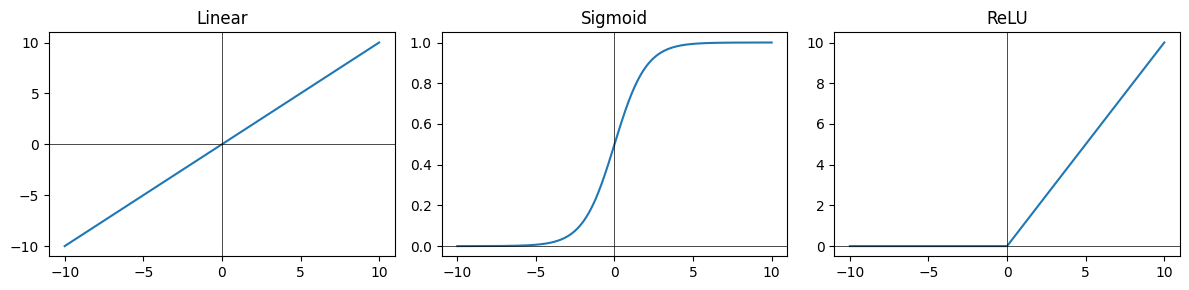

In [54]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 400)

linear = x
sigmoid = 1 / (1 + np.exp(-x))
relu = np.maximum(0, x)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

axes[0].plot(x, linear)
axes[0].set_title("Linear")
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].axvline(0, color='black', linewidth=0.5)

axes[1].plot(x, sigmoid)
axes[1].set_title("Sigmoid")
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].axvline(0, color='black', linewidth=0.5)

axes[2].plot(x, relu)
axes[2].set_title("ReLU")
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

Some of the common design choices we'll face when designing neural networks is:

- How many hidden layers do we want to use?
- How many units(neurons) in each layer?
- What activation function should be used for each layer?

This is for a feedforward (or vanilla) neural network. In general, the arrangement of neurons into layers, the activation functions, and the connections between layers are referred to as
the network’s architecture.

## Introducing PyTorch

![image](https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fpytorch.org%2Fwp-content%2Fuploads%2F2025%2F01%2Fpytorch_seo.png&f=1&nofb=1&ipt=7e8df52b4760d6fc272ae762fe51031f3f1d72d980c369aeb44c336376df1f95)

PyTorch is a Python-based scientific computing package serving two broad purposes:
- A replacement for NumPy to use the power of GPUs and other accelerators.
- An automatic differentiation library that is useful to implement neural networks.

In [55]:
import torch
import numpy as np

### Tensors

Tensors are a specialized data structure that are very similar to arrays and matrices. In PyTorch, we use tensors to encode the inputs and outputs of a model, as well as the model’s parameters.

In [56]:
data = [[1, 2], [3, 4]]
x_data = torch.tensor(data)

tensors can also be created from NumPy arrays 

In [57]:
np_array = np.array(data)
x_np = torch.from_numpy(np_array)

Tensor attributes describe their shape, datatype, and the device on which they are stored.

In [58]:
tensor = torch.rand(3, 4)

print(f"Shape of tensor: {tensor.shape}")
print(f"Datatype of tensor: {tensor.dtype}")
print(f"Device tensor is stored on: {tensor.device}")


Shape of tensor: torch.Size([3, 4])
Datatype of tensor: torch.float32
Device tensor is stored on: cpu


Over 100 tensor operations, including transposing, indexing, slicing, mathematical operations, linear algebra, random sampling, and more are comprehensively described [here](https://docs.pytorch.org/docs/2.11/torch.html).

Each of them can be run on the GPU (at typically higher speeds than on a CPU).

In [59]:
# We move our tensor to the GPU if available
if torch.cuda.is_available():
  tensor = tensor.to('cuda')
  print(f"Device tensor is stored on: {tensor.device}")

Device tensor is stored on: cuda:0


If you’re familiar with the NumPy API, you’ll find the Tensor API a breeze to use.

In [66]:
tensor = torch.ones(4, 4)
tensor[:,1] = 0
print(tensor)

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


In [68]:
print(tensor @ tensor.T) # matrix multiply

tensor([[3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.]])


For the next section let's set up some dummy data:

In [84]:
# Create *known* parameters
weight = 0.7
bias = 0.3

# Create data
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

In [85]:
# Create train/test split
train_split = int(0.8 * len(X)) # 80% of data used for training set, 20% for testing 
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [88]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

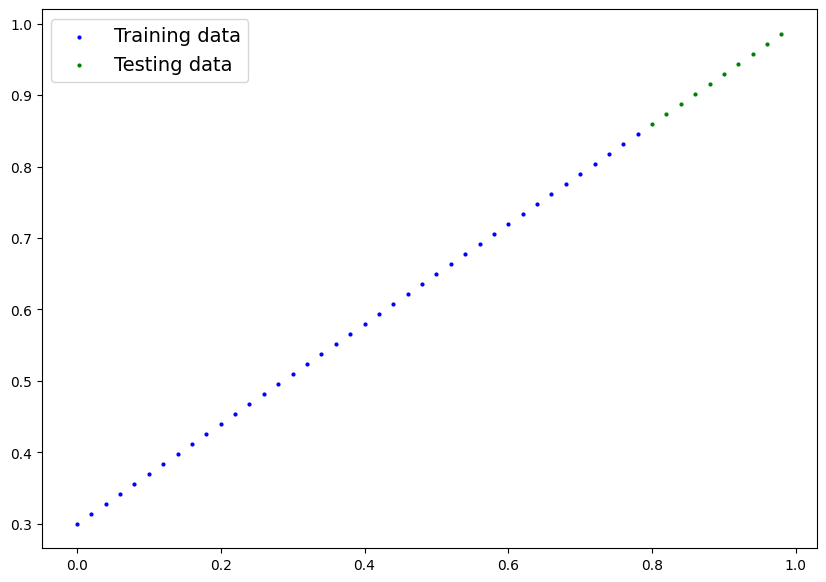

In [89]:
plot_predictions();

### Neural Networks

Neural networks (NNs) are a collection of nested functions that are executed on some input data. These functions are defined by parameters (consisting of weights and biases), which in PyTorch are stored in tensors.

Training a NN happens in two steps:
- **Forward Propagation**: In forward prop, the NN makes its best guess about the correct output. It runs the input data through each of its functions to make this guess.
- **Backward Propagation**: In backprop, the NN adjusts its parameters proportionate to the error in its guess. It does this by traversing backwards from the output, collecting the derivatives of the error with respect to the parameters of the functions (gradients), and optimizing the parameters using gradient descent.

![gif](https://github.com/xnought/backprop-explainer/raw/main/src/components/implementations/article/assets/demo.gif)

It is a simple feed-forward network. It takes the input, feeds it through several layers one after the other, and then finally gives the output.

A typical training procedure for a neural network is as follows:
- Define the neural network that has some learnable parameters (or weights)
- Iterate over a dataset of inputs
- Process input through the network
- Compute the loss (how far is the output from being correct)
- Propagate gradients back into the network’s parameters
- Update the weights of the network, typically using a simple update rule

Let’s define this network:

In [99]:
# Create a Linear Regression model class
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)
    def __init__(self):
        super().__init__() 
        self.weights = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                                dtype=torch.float), # <- PyTorch loves float32 by default
                                   requires_grad=True) # <- can we update this value with gradient descent?)

        self.bias = nn.Parameter(torch.randn(1, # <- start with random bias (this will get adjusted as the model learns)
                                            dtype=torch.float), # <- PyTorch loves float32 by default
                                requires_grad=True) # <- can we update this value with gradient descent?))

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data (e.g. training/testing features)
        return self.weights * x + self.bias # <- this is the linear regression formula (y = m*x + b)

![image](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01-pytorch-linear-model-annotated.png)

Now we've got these out of the way, let's create a model instance with the class we've made and check its parameters using `.parameters()`.

In [122]:
# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([-0.0739], requires_grad=True),
 Parameter containing:
 tensor([0.1015], requires_grad=True)]

Notice how the values for `weights` and `bias` from `model_0.state_dict()` come out as random float tensors?

This is because we initialized them above using `torch.randn()`.

Essentially we want to start from random parameters and get the model to update them towards parameters that fit our data best (the hardcoded `weight` and `bias` values we set when creating our straight line data).

### Making predictions using `torch.inference_mode()`

When we pass data to our model, it'll go through the model's forward() method and produce a result using the computation we've defined.

As the name suggests, `torch.inference_mode()` is used when using a model for inference (making predictions).

`torch.inference_mode()` turns off a bunch of things (like gradient tracking, which is necessary for training but not for inference) to make forward-passes (data going through the forward() method) faster.

In [123]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

In [124]:
for x,y in zip(y_test, y_preds):
    print(f'predicted: {x} | actual: {y}')

predicted: tensor([0.8600]) | actual: tensor([0.0424])
predicted: tensor([0.8740]) | actual: tensor([0.0409])
predicted: tensor([0.8880]) | actual: tensor([0.0394])
predicted: tensor([0.9020]) | actual: tensor([0.0380])
predicted: tensor([0.9160]) | actual: tensor([0.0365])
predicted: tensor([0.9300]) | actual: tensor([0.0350])
predicted: tensor([0.9440]) | actual: tensor([0.0335])
predicted: tensor([0.9580]) | actual: tensor([0.0320])
predicted: tensor([0.9720]) | actual: tensor([0.0306])
predicted: tensor([0.9860]) | actual: tensor([0.0291])


We've made some predictions, let's see what they look like.

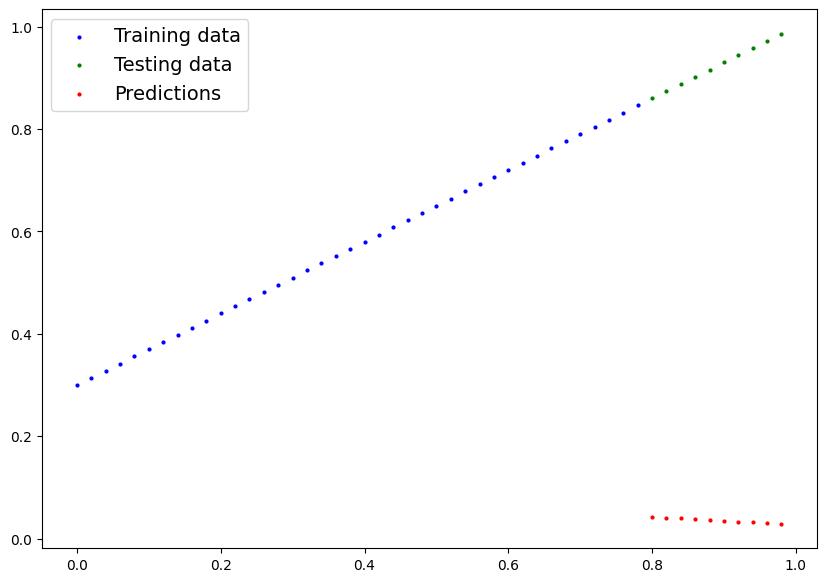

In [125]:
plot_predictions(predictions=y_preds)

![image](https://www.pngmart.com/files/11/Facepalm-PNG-File.png)

These...are awful. This makes sense though, when you remember our model is just using random parameter values to make predictions.

It hasn't even looked at the blue dots to try to predict the green dots.

Time to change that.

### Training Time

Right now our model is making predictions using random parameters to make calculations, it's basically guessing (randomly).

Let's create a loss function and an optimizer we can use to help improve our model.

For our problem, since we're predicting a number, let's use MAE (which is under `torch.nn.L1Loss()`) in PyTorch as our loss function.

![image](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01-mae-loss-annotated.png)

In [126]:
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(), # parameters of target model to optimize
                            lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

In [127]:
# Set the number of epochs (how many times the model will pass over the training data)
epochs = 500

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Caculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening
      if epoch % 25 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 0.5002951622009277 | MAE Test Loss: 0.8737937211990356 
Epoch: 25 | MAE Train Loss: 0.22254662215709686 | MAE Test Loss: 0.5441344380378723 
Epoch: 50 | MAE Train Loss: 0.12540492415428162 | MAE Test Loss: 0.34874090552330017 
Epoch: 75 | MAE Train Loss: 0.10612382739782333 | MAE Test Loss: 0.2679298520088196 
Epoch: 100 | MAE Train Loss: 0.09677048027515411 | MAE Test Loss: 0.23224382102489471 
Epoch: 125 | MAE Train Loss: 0.08804915100336075 | MAE Test Loss: 0.20538055896759033 
Epoch: 150 | MAE Train Loss: 0.07946144044399261 | MAE Test Loss: 0.18538609147071838 
Epoch: 175 | MAE Train Loss: 0.0708770602941513 | MAE Test Loss: 0.16470474004745483 
Epoch: 200 | MAE Train Loss: 0.06229283660650253 | MAE Test Loss: 0.1447102576494217 
Epoch: 225 | MAE Train Loss: 0.05370863527059555 | MAE Test Loss: 0.12471580505371094 
Epoch: 250 | MAE Train Loss: 0.04512440413236618 | MAE Test Loss: 0.1047213077545166 
Epoch: 275 | MAE Train Loss: 0.03653949499130249 | MAE 

Oh would you look at that! Looks like our loss is going down with every epoch, let's plot it to find out.

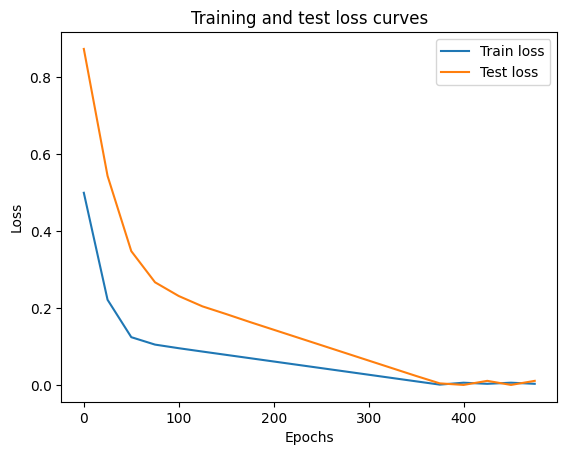

In [128]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

Nice! The loss curves show the loss going down over time. Remember, loss is the measure of how wrong your model is, so the lower the better.

But why did the loss go down?

Well, thanks to our loss function and optimizer, the model's internal parameters (`weights` and `bias`) were updated to better reflect the underlying patterns in the data.

Let's inspect our model's `.state_dict()` to see how close our model gets to the original values we set for weights and bias.

In [129]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: {weight}, bias: {bias}")

The model learned the following values for weights and bias:
OrderedDict({'weights': tensor([0.6904]), 'bias': tensor([0.2965])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


Our model got very close to calculating the exact original values for `weight` and `bias`.

This is the whole idea of machine learning and deep learning, there are some ideal values that describe our data and rather than figuring them out by hand, we can train a model to figure them out programmatically.

### Inference Mode

Once you've trained a model, you'll likely want to make predictions with it.

We've already seen a glimpse of this in the training and testing code above, the steps to do it outside of the training/testing loop are similar.

There are three things to remember when making predictions (also called performing inference) with a PyTorch model:

1. Set the model in evaluation mode (`model.eval()`).
2. Make the predictions using the inference mode context manager (`with torch.inference_mode(): ...`).
3. All predictions should be made with objects on the same device (e.g. data and model on GPU only or data and model on CPU only).

In [130]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
y_preds

tensor([[0.8488],
        [0.8626],
        [0.8765],
        [0.8903],
        [0.9041],
        [0.9179],
        [0.9317],
        [0.9455],
        [0.9593],
        [0.9731]])

Nice! We've made some predictions with our trained model, now how do they look?

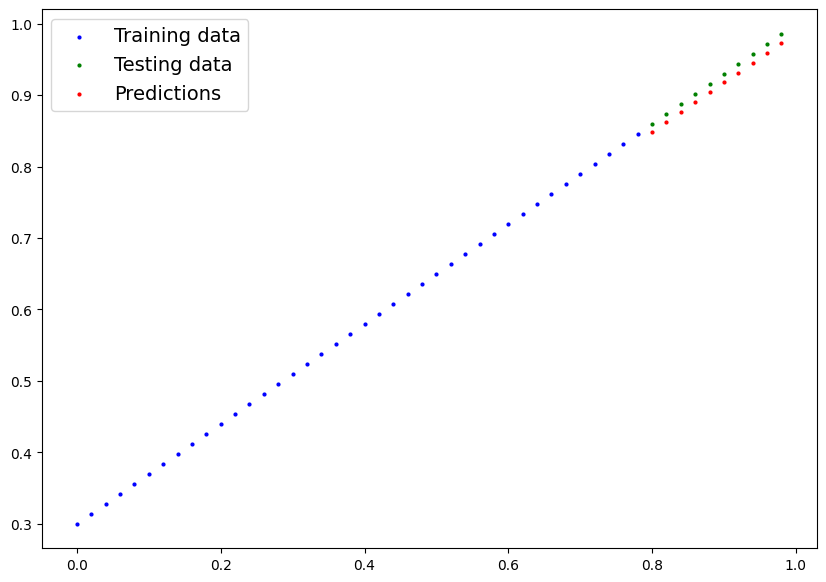

In [131]:
plot_predictions(predictions=y_preds)

Let's go back [here](https://playground.tensorflow.org) and take a look at a Neural Network.